# Esplorazione del dataset: feature reali e sintetiche

Questo notebook costituisce la base condivisa degli esperimenti. Documenta integrità e struttura dei dati, genera split e cache deterministiche, controlla duplicati e possibili confondenti. Non addestra modelli finali e non usa il test per analisi che possano influenzare le scelte sperimentali.

Mapping fissato: 0 = real e 1 = fake; fake è la classe positiva.

## 1. Setup e riproducibilità

La cella seguente definisce un solo contratto di percorsi. In locale usa la root del repository; in Colab monta Drive, verifica i due file originali e li copia nella memoria temporanea veloce della VM. I dati derivati e i risultati restano invece nella directory persistente.

In [1]:
# Configurazione portabile dei percorsi: questa è l'unica cella con un ramo locale/Colab.
from pathlib import Path
import importlib.util
import shutil

# Importare direttamente il modulo Colab evita find_spec, che in locale può fallire se il namespace google è assente.
try:
    from google.colab import drive as colab_drive
    IS_COLAB = True
except ImportError:
    colab_drive = None
    IS_COLAB = False
EXPECTED_FILES = {'features_0.npy': 2_167_931_008, 'features_1.npy': 3_123_445_888}

if IS_COLAB:
    DRIVE_MOUNT = Path('/content/drive')
    if not (DRIVE_MOUNT / 'MyDrive').exists():
        colab_drive.mount(str(DRIVE_MOUNT), force_remount=False)
    PROJECT_ROOT = DRIVE_MOUNT / 'MyDrive' / 'Magistrale' / 'Advanced_ML' / 'progetto_aml'
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    if not PERSISTENT_DATASET_DIR.is_dir():
        raise FileNotFoundError(f'Dataset directory non trovata su Drive: {PERSISTENT_DATASET_DIR}')
    RUNTIME_DATASET_DIR = Path('/content/progetto_aml/dataset')
    RUNTIME_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    # I grandi file NPY vengono letti dalla VM; la copia è riusata quando dimensione e presenza coincidono.
    for filename, expected_size in EXPECTED_FILES.items():
        source, destination = PERSISTENT_DATASET_DIR / filename, RUNTIME_DATASET_DIR / filename
        if not source.is_file():
            raise FileNotFoundError(f'File non trovato su Drive: {source}')
        if source.stat().st_size != expected_size:
            raise RuntimeError(f'Dimensione non valida per {source}: {source.stat().st_size}; attesi {expected_size}')
        if not destination.exists() or destination.stat().st_size != expected_size:
            print(f'Copio {filename} da Drive nella VM Colab')
            shutil.copy2(source, destination)
        if destination.stat().st_size != expected_size:
            raise RuntimeError(f'Copia incompleta: {destination}')
    DATASET_DIR = RUNTIME_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / 'artifacts', PROJECT_ROOT / 'results'
else:
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'dataset').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    DATASET_DIR = PERSISTENT_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR, RESULTS_DIR = PROJECT_ROOT / 'artifacts', PROJECT_ROOT / 'results'

if not PERSISTENT_DATASET_DIR.is_dir():
    raise FileNotFoundError(f'Dataset directory non trovata: {PERSISTENT_DATASET_DIR}')
for directory in (PROCESSED_DATASET_DIR, ARTIFACTS_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print('Ambiente:', 'Google Colab' if IS_COLAB else 'Locale')
print('Dataset per lettura:', DATASET_DIR)
print('Dataset persistente:', PROCESSED_DATASET_DIR)

Ambiente: Locale
Dataset per lettura: c:\Users\leona\venv_aml\dataset
Dataset persistente: c:\Users\leona\venv_aml\dataset


In [2]:
# Installa solo le dipendenze mancanti, imposta i seed e crea una directory di run non sovrascrivibile.
import subprocess
import sys

required_packages = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'sklearn': 'scikit-learn'}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing])

import ast
import hashlib
import json
import os
import platform
import random
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import torch
except ImportError:
    torch = None

SEED, BATCH_SIZE, EPSILON = 42, 8, 1e-6
RUN_ID = f'seed{SEED}_{datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")}'
RUN_DIR = RESULTS_DIR / 'dataset_exploration' / RUN_ID
FIGURES_DIR = RUN_DIR / 'figures'
RUN_DIR.mkdir(parents=True, exist_ok=False)
FIGURES_DIR.mkdir(parents=True, exist_ok=False)

random.seed(SEED)
np.random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except AttributeError:
        pass

VERSIONS = {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__, 'scikit_learn': __import__('sklearn').__version__, 'pytorch': None if torch is None else torch.__version__, 'cuda': None if torch is None or not torch.cuda.is_available() else torch.version.cuda}
print(json.dumps(VERSIONS, indent=2))
print('Device:', 'cuda' if torch is not None and torch.cuda.is_available() else 'cpu')
print('Run directory:', RUN_DIR)

{
  "python": "3.12.10",
  "numpy": "2.5.2",
  "pandas": "3.0.5",
  "scikit_learn": "1.9.1",
  "pytorch": "2.14.0+cu126",
  "cuda": "12.6"
}
Device: cuda
Run directory: c:\Users\leona\venv_aml\results\dataset_exploration\seed42_20260916T132745Z


## 2. Configurazione delle classi e utilità

Il mapping dei file verso le classi è dichiarato esplicitamente e non è inferito dai nomi. Le funzioni qui sotto effettuano salvataggi atomici: un file parziale non sostituisce mai un artefatto valido.

In [3]:
# Convenzione comune a tutti i notebook: fake è la classe positiva per precision, recall, F1 e PR-AUC.
CLASS_MAPPING = {'features_0.npy': {'label': 0, 'name': 'real'}, 'features_1.npy': {'label': 1, 'name': 'fake'}}
POSITIVE_LABEL, POSITIVE_CLASS = 1, 'fake'
EXPECTED_SAMPLE_SHAPE, EXPECTED_DTYPE = (1280, 16, 16), np.dtype('float32')
assert CLASS_MAPPING['features_1.npy'] == {'label': POSITIVE_LABEL, 'name': POSITIVE_CLASS}

def atomic_json(payload, path):
    temporary = path.with_name(path.name + '.tmp')
    with temporary.open('w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False, default=str)
    os.replace(temporary, path)

def atomic_csv(frame, path):
    temporary = path.with_name(path.name + '.tmp')
    frame.to_csv(temporary, index=False)
    os.replace(temporary, path)

def save_npz(path, **arrays):
    temporary = path.with_name(path.name + '.tmp')
    with temporary.open('wb') as handle:
        np.savez_compressed(handle, **arrays)
    os.replace(temporary, path)

def npy_inventory(path):
    # Legge solo header e piccoli blocchi iniziale/finale: non carica il tensore in RAM.
    # Il parsing è esplicito per non dipendere da funzioni private di NumPy, variabili tra versioni.
    with path.open('rb') as handle:
        version = np.lib.format.read_magic(handle)
        if version == (1, 0):
            header_length = int.from_bytes(handle.read(2), 'little')
            header_encoding = 'latin1'
        elif version in {(2, 0), (3, 0)}:
            header_length = int.from_bytes(handle.read(4), 'little')
            header_encoding = 'utf-8' if version == (3, 0) else 'latin1'
        else:
            raise RuntimeError(f'Versione NPY non supportata: {version}')
        header = ast.literal_eval(handle.read(header_length).decode(header_encoding).strip())
        shape = tuple(int(value) for value in header['shape'])
        fortran_order = bool(header['fortran_order'])
        dtype = np.dtype(header['descr'])
        payload_offset = handle.tell()
    expected_bytes = payload_offset + int(np.prod(shape, dtype=np.int64)) * dtype.itemsize
    if path.stat().st_size != expected_bytes:
        raise RuntimeError(f'Header NPY incoerente con la dimensione del file: {path}')
    digest = hashlib.sha256()
    block = min(1_048_576, path.stat().st_size)
    with path.open('rb') as handle:
        digest.update(handle.read(block))
        if path.stat().st_size > block:
            handle.seek(path.stat().st_size - block)
            digest.update(handle.read(block))
    return {'relative_path': path.name, 'size_bytes': path.stat().st_size, 'size_gib': path.stat().st_size / 1024**3, 'npy_version': f'{version[0]}.{version[1]}', 'shape': list(shape), 'dtype': dtype.str, 'byte_order': 'little' if dtype.byteorder in {'<', '=', '|'} else 'big', 'fortran_order': bool(fortran_order), 'n_samples': int(shape[0]), 'bytes_per_sample': int(np.prod(shape[1:], dtype=np.int64)) * dtype.itemsize, 'fingerprint_method': 'sha256(first_1MiB + last_1MiB)', 'fingerprint': digest.hexdigest()}

def split_hash(train_indices, validation_indices, test_indices):
    digest = hashlib.sha256()
    for name, indices in (('train', train_indices), ('validation', validation_indices), ('test', test_indices)):
        digest.update(name.encode('utf-8'))
        digest.update(np.asarray(indices, dtype='<i8').tobytes())
    return digest.hexdigest()

def validate_splits(train_indices, validation_indices, test_indices, labels):
    parts = [np.asarray(part, dtype=np.int64) for part in (train_indices, validation_indices, test_indices)]
    all_indices = np.concatenate(parts)
    if len(np.unique(all_indices)) != len(labels) or set(all_indices) != set(range(len(labels))):
        raise RuntimeError('Split non disgiunti o non esaustivi')
    if any(part.min() < 0 or part.max() >= len(labels) for part in parts):
        raise RuntimeError('Indice di split fuori range')
    return {name: {'n_samples': int(len(part)), 'class_counts': {str(label): int((labels[part] == label).sum()) for label in (0, 1)}} for name, part in zip(('train', 'validation', 'test'), parts)}

def save_figure(name):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / name, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

## 3. Caricamento, inventario e split condiviso

I tensori originali sono aperti con memory mapping e non vengono concatenati. Lo split stratificato 70/15/15 viene creato solo se assente, poi validato e identificato da un hash stabile.

In [4]:
# L'apertura tramite mmap lascia i dati su disco e legge in RAM solo i batch richiesti in seguito.
open_started = time.perf_counter()
features_real = np.load(DATASET_DIR / 'features_0.npy', mmap_mode='r', allow_pickle=False)
features_fake = np.load(DATASET_DIR / 'features_1.npy', mmap_mode='r', allow_pickle=False)
mmap_open_seconds = time.perf_counter() - open_started
for array in (features_real, features_fake):
    assert array.shape[1:] == EXPECTED_SAMPLE_SHAPE
    assert array.dtype == EXPECTED_DTYPE

INVENTORIES = {'features_0.npy': npy_inventory(DATASET_DIR / 'features_0.npy'), 'features_1.npy': npy_inventory(DATASET_DIR / 'features_1.npy')}
N_REAL, N_FAKE = len(features_real), len(features_fake)
N_TOTAL = N_REAL + N_FAKE
labels = np.concatenate((np.zeros(N_REAL, dtype=np.int8), np.ones(N_FAKE, dtype=np.int8)))
source_files = np.array(['features_0.npy'] * N_REAL + ['features_1.npy'] * N_FAKE, dtype=object)
source_indices = np.concatenate((np.arange(N_REAL), np.arange(N_FAKE))).astype(np.int64)
sample_ids = np.array([f'features_0:{index}' for index in range(N_REAL)] + [f'features_1:{index}' for index in range(N_FAKE)], dtype=object)
print(f'Real: {features_real.shape}; fake: {features_fake.shape}; mmap: {mmap_open_seconds:.3f} s')

def feature_batches(batch_size=BATCH_SIZE):
    # Restituisce piccoli batch e l'indice globale; evita una concatenazione dei due file spaziali.
    for source, array, offset in (('features_0.npy', features_real, 0), ('features_1.npy', features_fake, N_REAL)):
        for start in range(0, len(array), batch_size):
            stop = min(start + batch_size, len(array))
            yield source, offset + start, np.asarray(array[start:stop], dtype=np.float32)

SPLIT_PATH = ARTIFACTS_DIR / 'splits_seed42.npz'
# Riutilizzare lo split già salvato evita di cambiare le partizioni tra notebook o riesecuzioni.
if SPLIT_PATH.exists():
    with np.load(SPLIT_PATH, allow_pickle=False) as archive:
        train_indices = archive['train_indices'].astype(np.int64, copy=False)
        validation_indices = archive['validation_indices'].astype(np.int64, copy=False)
        test_indices = archive['test_indices'].astype(np.int64, copy=False)
    split_origin = 'loaded'
else:
    all_indices = np.arange(N_TOTAL, dtype=np.int64)
    train_indices, holdout_indices = train_test_split(all_indices, test_size=0.30, stratify=labels, random_state=SEED)
    validation_indices, test_indices = train_test_split(holdout_indices, test_size=0.50, stratify=labels[holdout_indices], random_state=SEED)
    train_indices, validation_indices, test_indices = map(np.sort, (train_indices, validation_indices, test_indices))
    save_npz(SPLIT_PATH, train_indices=train_indices, validation_indices=validation_indices, test_indices=test_indices)
    split_origin = 'created'
SPLIT_SUMMARY = validate_splits(train_indices, validation_indices, test_indices, labels)
SPLIT_HASH = split_hash(train_indices, validation_indices, test_indices)
split_names = np.full(N_TOTAL, 'unassigned', dtype=object)
split_names[train_indices], split_names[validation_indices], split_names[test_indices] = 'train', 'validation', 'test'
sample_index = pd.DataFrame({'sample_id': sample_ids, 'source_file': source_files, 'source_index': source_indices, 'label': labels, 'split': split_names})
atomic_csv(sample_index, PROCESSED_DATASET_DIR / 'sample_index.csv')
print('Split:', split_origin, SPLIT_HASH)
print(json.dumps(SPLIT_SUMMARY, indent=2))

Real: (1654, 1280, 16, 16); fake: (2383, 1280, 16, 16); mmap: 0.002 s
Split: created e23bd01e9ec079e665ed5cb58cdba6c190d40bb702919412e2f5f5aeca63cbd6
{
  "train": {
    "n_samples": 2825,
    "class_counts": {
      "0": 1157,
      "1": 1668
    }
  },
  "validation": {
    "n_samples": 606,
    "class_counts": {
      "0": 248,
      "1": 358
    }
  },
  "test": {
    "n_samples": 606,
    "class_counts": {
      "0": 249,
      "1": 357
    }
  }
}


## 4. Qualità numerica, duplicati esatti e cache GAP e mean+std

Un unico passaggio streaming controlla valori non finiti, statistiche globali e hash binari dei campioni. Nello stesso passaggio crea, se necessario, le due cache tabulari deterministiche: GAP a 1280 feature e mean+std a 2560 feature.

In [5]:
# Le cache sono dati preprocessati persistenti: in Colab vengono scritte su Drive, mai solo nella VM.
GAP_PATH = PROCESSED_DATASET_DIR / 'tabular_features_gap.npy'
MEAN_STD_PATH = PROCESSED_DATASET_DIR / 'tabular_features_mean_std.npy'

def is_valid_cache(path, shape):
    if not path.is_file():
        return False
    array = np.load(path, mmap_mode='r', allow_pickle=False)
    return array.shape == shape and array.dtype == np.float32

# Una cache esistente è riusata solo dopo averne verificato forma e dtype.
build_cache = not (is_valid_cache(GAP_PATH, (N_TOTAL, 1280)) and is_valid_cache(MEAN_STD_PATH, (N_TOTAL, 2560)))
if build_cache:
    gap_temporary = GAP_PATH.with_name(GAP_PATH.name + '.pending')
    mean_std_temporary = MEAN_STD_PATH.with_name(MEAN_STD_PATH.name + '.pending')
    gap_cache = np.lib.format.open_memmap(gap_temporary, mode='w+', dtype=np.float32, shape=(N_TOTAL, 1280))
    mean_std_cache = np.lib.format.open_memmap(mean_std_temporary, mode='w+', dtype=np.float32, shape=(N_TOTAL, 2560))

sample_stats = np.empty((N_TOTAL, 6), dtype=np.float64)
sample_hashes = np.empty(N_TOTAL, dtype=object)
quality = {'nan_count': 0, 'inf_count': 0, 'zero_count': 0, 'value_count': 0, 'sum': 0.0, 'sum_squares': 0.0, 'minimum': np.inf, 'maximum': -np.inf}
random_values, rng = [], np.random.default_rng(SEED)
stream_started = time.perf_counter()
for _, global_start, batch in feature_batches():
    global_stop, flat = global_start + len(batch), batch.reshape(len(batch), -1)
    quality['nan_count'] += int(np.isnan(batch).sum())
    quality['inf_count'] += int(np.isinf(batch).sum())
    quality['zero_count'] += int((batch == 0).sum())
    quality['value_count'] += int(batch.size)
    quality['sum'] += float(np.sum(batch, dtype=np.float64))
    quality['sum_squares'] += float(np.sum(np.square(batch, dtype=np.float64), dtype=np.float64))
    quality['minimum'], quality['maximum'] = min(quality['minimum'], float(batch.min())), max(quality['maximum'], float(batch.max()))
    sample_stats[global_start:global_stop] = np.column_stack((flat.mean(1, dtype=np.float64), flat.std(1, dtype=np.float64), flat.min(1), flat.max(1), np.abs(flat).sum(1, dtype=np.float64), np.sqrt(np.square(flat, dtype=np.float64).sum(1, dtype=np.float64))))
    # L'hash sui byte originali consente di rilevare duplicati esatti sia tra classi sia tra split.
    for local_index, sample in enumerate(batch):
        sample_hashes[global_start + local_index] = hashlib.blake2b(sample.tobytes(), digest_size=16).hexdigest()
    if build_cache:
        channel_mean = batch.mean(axis=(2, 3), dtype=np.float32)
        channel_std = batch.std(axis=(2, 3), dtype=np.float32, ddof=0)
        gap_cache[global_start:global_stop] = channel_mean
        mean_std_cache[global_start:global_stop] = np.concatenate((channel_mean, channel_std), axis=1)
    values = batch.reshape(-1)
    n_draw = min(2048, len(values))
    random_values.append(values[rng.choice(len(values), size=n_draw, replace=False)].copy())

if quality['nan_count'] or quality['inf_count']:
    raise ValueError(f'Dati non finiti: NaN={quality["nan_count"]}; Inf={quality["inf_count"]}')
if build_cache:
    gap_cache.flush()
    mean_std_cache.flush()
    del gap_cache, mean_std_cache
    os.replace(gap_temporary, GAP_PATH)
    os.replace(mean_std_temporary, MEAN_STD_PATH)
quality['mean'] = quality['sum'] / quality['value_count']
quality['std'] = float(np.sqrt(max(quality['sum_squares'] / quality['value_count'] - quality['mean'] ** 2, 0.0)))
quality['zero_fraction'] = quality['zero_count'] / quality['value_count']
quantile_sample = np.concatenate(random_values)
quality['robust_percentiles_deterministic_sample'] = {str(q): float(np.percentile(quantile_sample, q)) for q in (0.1, 1, 5, 50, 95, 99, 99.9)}
quality['stream_seconds'], quality['quantile_sample_size'] = time.perf_counter() - stream_started, int(len(quantile_sample))
hash_frame = sample_index.copy()
hash_frame['sample_hash'] = sample_hashes
exact_duplicates = hash_frame.groupby('sample_hash', sort=False).filter(lambda group: len(group) > 1).sort_values('sample_hash')
duplicate_summary = {'duplicate_rows': int(len(exact_duplicates)), 'duplicate_groups': int(exact_duplicates['sample_hash'].nunique()), 'cross_class_groups': int(exact_duplicates.groupby('sample_hash')['label'].nunique().gt(1).sum()) if len(exact_duplicates) else 0, 'cross_split_groups': int(exact_duplicates.groupby('sample_hash')['split'].nunique().gt(1).sum()) if len(exact_duplicates) else 0}
atomic_csv(exact_duplicates, RUN_DIR / 'exact_duplicate_groups.csv')
print(f'Stream completato in {quality["stream_seconds"]:.1f} s. Cache create: {build_cache}')
print(duplicate_summary)

Stream completato in 55.4 s. Cache create: True
{'duplicate_rows': 0, 'duplicate_groups': 0, 'cross_class_groups': 0, 'cross_split_groups': 0}


## 5. Statistiche di normalizzazione spaziale calcolate sul training

Per CNN spatial head e ConvNeXt questa cella calcola media e deviazione standard di ogni canale sulle sole osservazioni di training e su tutte le loro posizioni 16x16. Validation e test non contribuiscono alle statistiche.

In [6]:
# Queste statistiche saranno riusate identiche da entrambi i modelli spaziali.
NORMALIZATION_PATH = PROCESSED_DATASET_DIR / 'spatial_channel_normalization.npz'
train_mask = np.zeros(N_TOTAL, dtype=bool)
train_mask[train_indices] = True
channel_sum, channel_sum_squares, normalization_count = np.zeros(1280, dtype=np.float64), np.zeros(1280, dtype=np.float64), 0
# Il mask seleziona soltanto indici train; la scansione resta comunque a batch per contenere la RAM.
for _, global_start, batch in feature_batches():
    selected = batch[train_mask[global_start:global_start + len(batch)]]
    if len(selected):
        channel_sum += selected.sum(axis=(0, 2, 3), dtype=np.float64)
        channel_sum_squares += np.square(selected, dtype=np.float64).sum(axis=(0, 2, 3), dtype=np.float64)
        normalization_count += selected.shape[0] * 16 * 16
channel_mean = (channel_sum / normalization_count).astype(np.float32)
channel_std = np.sqrt(np.maximum(channel_sum_squares / normalization_count - channel_mean.astype(np.float64) ** 2, 0.0)).astype(np.float32)
save_npz(NORMALIZATION_PATH, channel_mean=channel_mean, channel_std=channel_std, epsilon=np.float32(EPSILON), dtype=np.array('float32'), split_hash=np.array(SPLIT_HASH), training_samples=np.int64(len(train_indices)), values_per_channel=np.int64(normalization_count))
assert channel_mean.shape == (1280,) and channel_std.shape == (1280,)
assert np.isfinite(channel_mean).all() and np.isfinite(channel_std).all()
print('Normalizzazione spaziale salvata:', NORMALIZATION_PATH)

Normalizzazione spaziale salvata: c:\Users\leona\venv_aml\dataset\spatial_channel_normalization.npz


## 6. Analisi class-conditional, near-duplicate e outlier sul solo training

Da questo punto le analisi che possono guidare scelte progettuali vedono esclusivamente il training. Gli effect size guidano la selezione dei canali visualizzati; PCA e nearest-neighbor servono a segnalare near-duplicate e outlier, senza rimuovere automaticamente alcun campione.

In [7]:
# Le cache sono aperte in mmap; solo le righe train vengono materializzate per PCA e statistiche.
gap_features = np.load(GAP_PATH, mmap_mode='r', allow_pickle=False)
mean_std_features = np.load(MEAN_STD_PATH, mmap_mode='r', allow_pickle=False)
assert gap_features.shape == (N_TOTAL, 1280) and mean_std_features.shape == (N_TOTAL, 2560)
train_gap = np.asarray(gap_features[train_indices], dtype=np.float32)
train_mean_std = np.asarray(mean_std_features[train_indices], dtype=np.float32)
train_labels = labels[train_indices]
real_gap, fake_gap = train_gap[train_labels == 0], train_gap[train_labels == 1]
effect = (fake_gap.mean(0, dtype=np.float64) - real_gap.mean(0, dtype=np.float64)) / np.maximum(np.sqrt((fake_gap.var(0, dtype=np.float64) + real_gap.var(0, dtype=np.float64)) / 2), EPSILON)
channel_statistics = pd.DataFrame({'channel': np.arange(1280), 'train_mean_real': real_gap.mean(0), 'train_mean_fake': fake_gap.mean(0), 'effect_size_fake_minus_real': effect, 'absolute_effect_size': np.abs(effect), 'overall_train_variance': train_gap.var(0)})
channel_statistics['rank_by_absolute_effect'] = channel_statistics['absolute_effect_size'].rank(ascending=False, method='first').astype(int)
atomic_csv(channel_statistics.sort_values('rank_by_absolute_effect'), RUN_DIR / 'channel_statistics.csv')
top_channels = channel_statistics.nlargest(20, 'absolute_effect_size')['channel'].to_numpy(dtype=int)
effect_size_fractions = {str(t): float((np.abs(effect) >= t).mean()) for t in (0.2, 0.5, 0.8, 1.0)}

# Lo scaler e la PCA sono fit sul training soltanto e non vengono usati come preprocessing dei modelli finali.
pca_input = StandardScaler().fit_transform(train_mean_std)
n_components = min(50, pca_input.shape[0] - 1, pca_input.shape[1])
pca = PCA(n_components=n_components, svd_solver='randomized', random_state=SEED)
train_pca = pca.fit_transform(pca_input)
neighbors = NearestNeighbors(n_neighbors=2).fit(train_pca)
neighbor_distances, neighbor_positions = neighbors.kneighbors(train_pca)
near_rows = []
for left, right in enumerate(neighbor_positions[:, 1]):
    if left < right:
        left_id, right_id = train_indices[left], train_indices[right]
        near_rows.append({'sample_id_a': sample_ids[left_id], 'sample_id_b': sample_ids[right_id], 'label_a': int(labels[left_id]), 'label_b': int(labels[right_id]), 'split_a': 'train', 'split_b': 'train', 'pca_euclidean_distance': float(neighbor_distances[left, 1]), 'same_class': bool(labels[left_id] == labels[right_id])})
near_duplicates = pd.DataFrame(near_rows).sort_values('pca_euclidean_distance').head(200)
atomic_csv(near_duplicates, RUN_DIR / 'near_duplicates.csv')

train_stats = sample_stats[train_indices]
median, mad = np.median(train_stats, axis=0), np.median(np.abs(train_stats - np.median(train_stats, axis=0)), axis=0)
robust_score = np.max(np.abs(0.6745 * (train_stats - median) / np.maximum(mad, EPSILON)), axis=1)
pca_distance, nn_distance = np.sqrt(np.square(train_pca[:, :10]).sum(1)), neighbor_distances[:, 1]
rank_score = pd.Series(robust_score).rank(pct=True).to_numpy() + pd.Series(pca_distance).rank(pct=True).to_numpy() + pd.Series(nn_distance).rank(pct=True).to_numpy()
outliers = pd.DataFrame({'sample_id': sample_ids[train_indices], 'source_file': source_files[train_indices], 'source_index': source_indices[train_indices], 'label': train_labels, 'split': 'train', 'robust_global_stat_score': robust_score, 'pca_distance': pca_distance, 'nearest_neighbor_distance': nn_distance, 'combined_rank_score': rank_score, 'reason': 'robust global statistics, PCA distance, nearest-neighbor distance'}).nlargest(50, 'combined_rank_score')
atomic_csv(outliers, RUN_DIR / 'outlier_candidates.csv')

## 7. Figure per relazione

Le figure seguenti sono salvate prima della visualizzazione, a 200 DPI. I confronti tra classi usano il training; distribuzione e inventario possono invece descrivere l'intero dataset perché non sono usati per scegliere il modello.

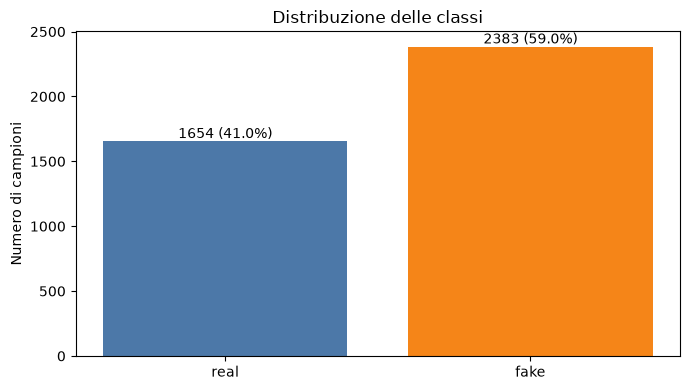

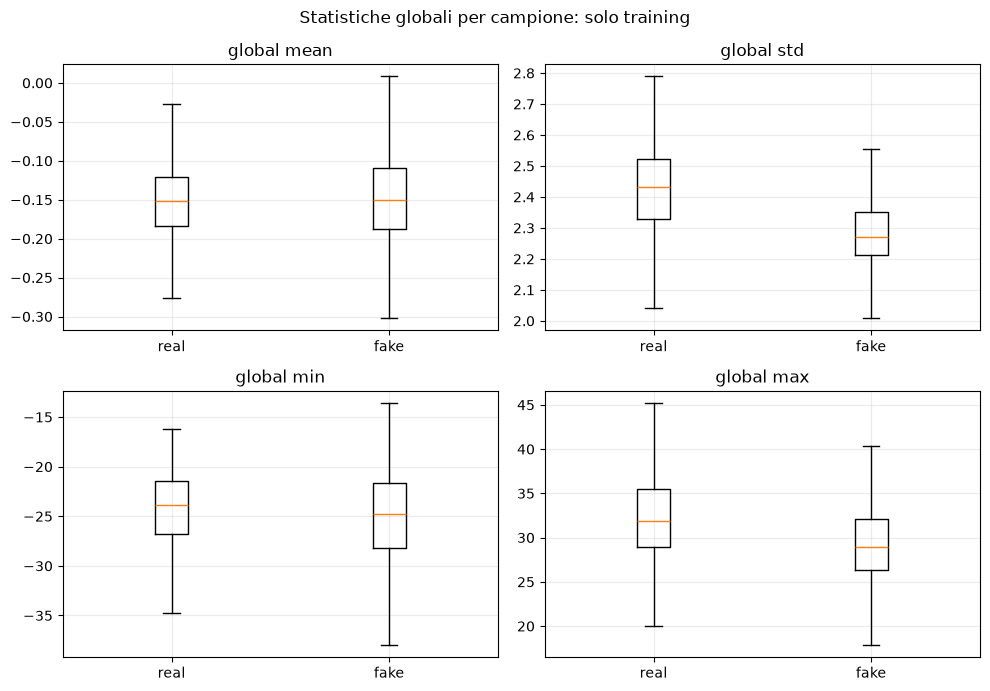

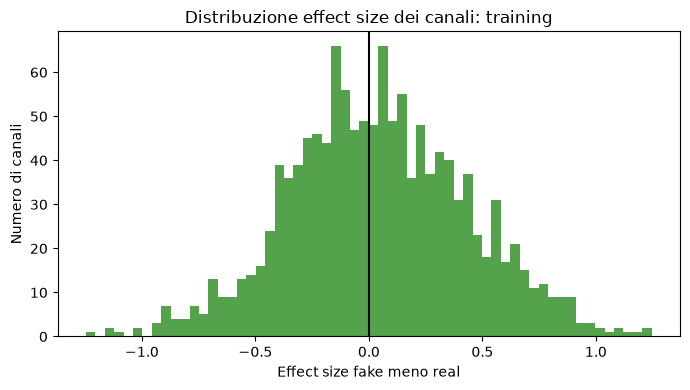

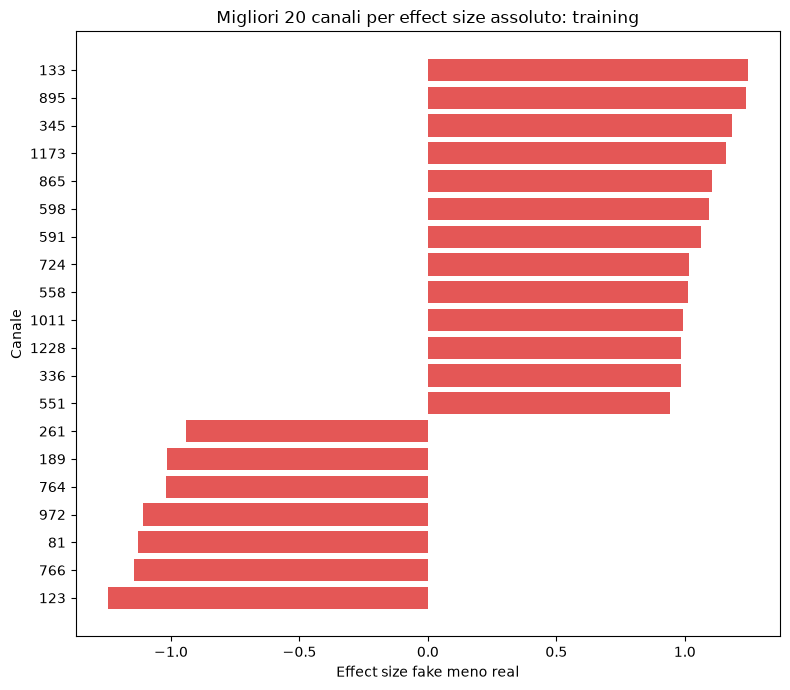

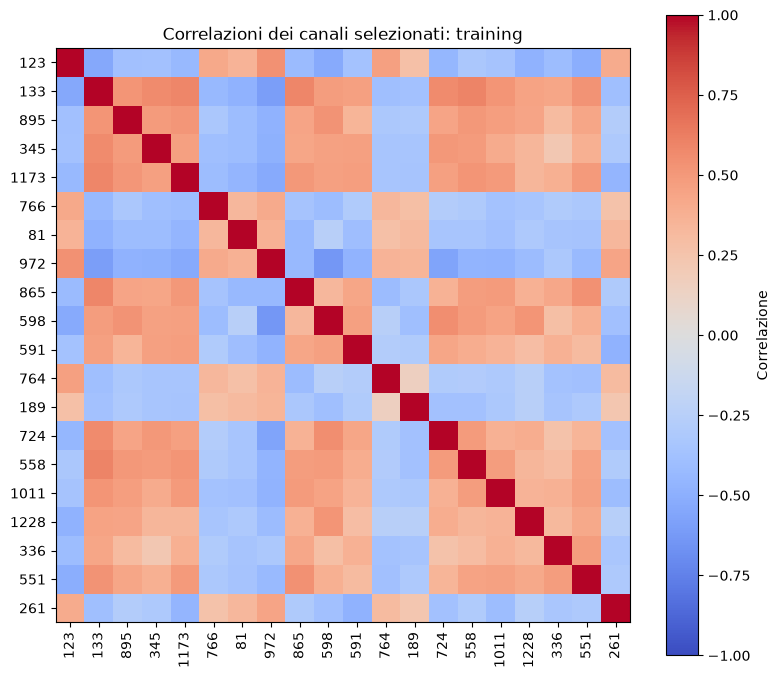

In [8]:
# Conteggi descrittivi sull'intero dataset; non contengono una trasformazione appresa.
plt.figure(figsize=(7, 4))
counts = pd.Series({'real': N_REAL, 'fake': N_FAKE})
bars = plt.bar(counts.index, counts.values, color=['#4c78a8', '#f58518'])
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, count, f'{count} ({count / N_TOTAL:.1%})', ha='center', va='bottom')
plt.title('Distribuzione delle classi')
plt.ylabel('Numero di campioni')
save_figure('class_distribution.png')

stats_frame = pd.DataFrame(sample_stats, columns=['global_mean', 'global_std', 'global_min', 'global_max', 'l1_norm', 'l2_norm'])
stats_frame['class_name'], stats_frame['split'] = np.where(labels == 1, 'fake', 'real'), split_names
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for axis, column in zip(axes.ravel(), ['global_mean', 'global_std', 'global_min', 'global_max']):
    values = [stats_frame.loc[(stats_frame.split == 'train') & (stats_frame.class_name == name), column] for name in ('real', 'fake')]
    axis.boxplot(values, tick_labels=['real', 'fake'], showfliers=False)
    axis.set_title(column.replace('_', ' '))
    axis.grid(alpha=0.25)
fig.suptitle('Statistiche globali per campione: solo training')
save_figure('sample_global_statistics.png')

plt.figure(figsize=(7, 4))
plt.hist(effect, bins=60, color='#54a24b')
plt.axvline(0, color='black')
plt.title('Distribuzione effect size dei canali: training')
plt.xlabel('Effect size fake meno real')
plt.ylabel('Numero di canali')
save_figure('channel_effect_size_distribution.png')

top_plot = channel_statistics.nlargest(20, 'absolute_effect_size').sort_values('effect_size_fake_minus_real')
plt.figure(figsize=(8, 7))
plt.barh(top_plot.channel.astype(str), top_plot.effect_size_fake_minus_real, color='#e45756')
plt.title('Migliori 20 canali per effect size assoluto: training')
plt.xlabel('Effect size fake meno real')
plt.ylabel('Canale')
save_figure('top_channels.png')

correlation = np.corrcoef(train_gap[:, top_channels], rowvar=False)
plt.figure(figsize=(8, 7))
image = plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(image, label='Correlazione')
plt.xticks(range(len(top_channels)), top_channels, rotation=90)
plt.yticks(range(len(top_channels)), top_channels)
plt.title('Correlazioni dei canali selezionati: training')
save_figure('selected_channel_correlation.png')

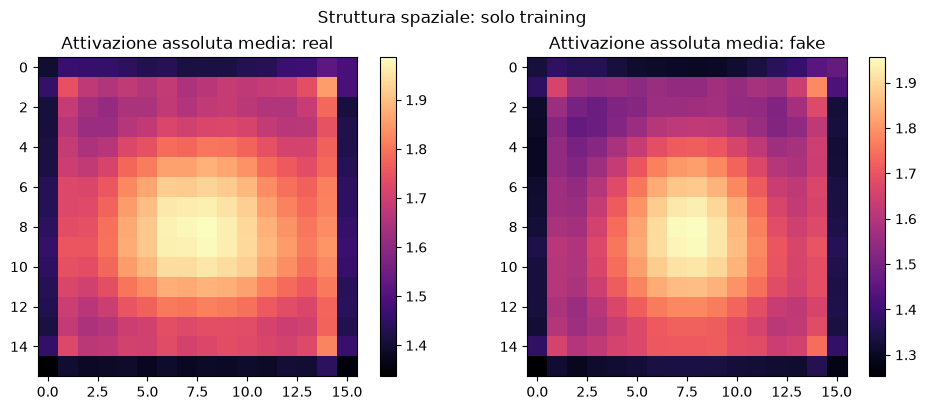

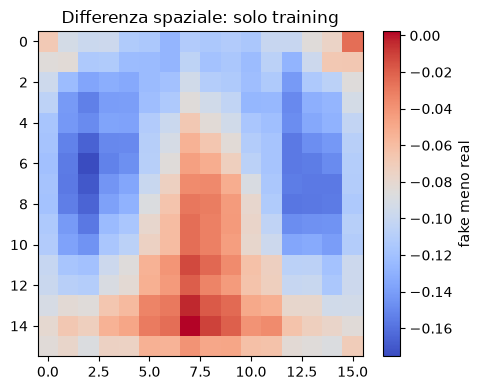

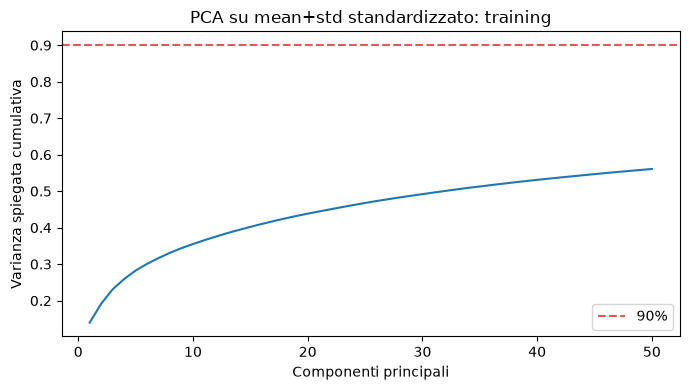

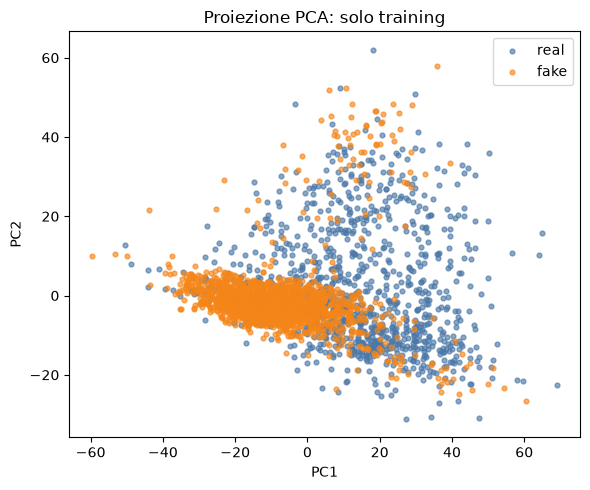

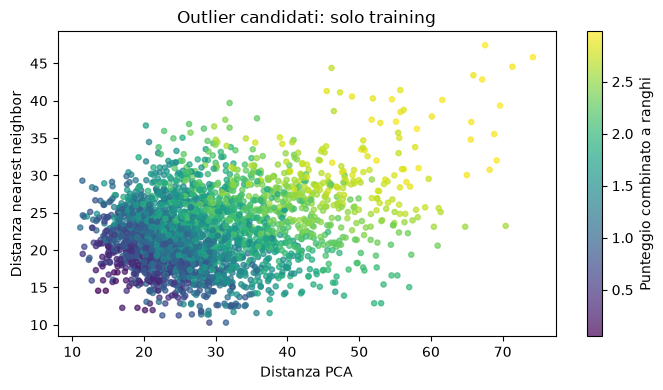

In [9]:
# Le mappe spaziali condensano i 1280 canali; sono aggregate solo dai campioni di training.
spatial_sums = {0: np.zeros((16, 16), dtype=np.float64), 1: np.zeros((16, 16), dtype=np.float64)}
spatial_counts = {0: 0, 1: 0}
spatial_square_sum = np.zeros((16, 16), dtype=np.float64)
for _, global_start, batch in feature_batches():
    global_ids = np.arange(global_start, global_start + len(batch))
    selected = batch[train_mask[global_ids]]
    selected_labels = labels[global_ids[train_mask[global_ids]]]
    if len(selected):
        activation = np.abs(selected).mean(axis=1, dtype=np.float64)
        spatial_square_sum += np.square(activation).sum(axis=0)
        for label in (0, 1):
            current = activation[selected_labels == label]
            if len(current):
                spatial_sums[label] += current.sum(axis=0)
                spatial_counts[label] += len(current)
spatial_real, spatial_fake = spatial_sums[0] / spatial_counts[0], spatial_sums[1] / spatial_counts[1]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, image_data, name in zip(axes, (spatial_real, spatial_fake), ('real', 'fake')):
    image = axis.imshow(image_data, cmap='magma')
    axis.set_title(f'Attivazione assoluta media: {name}')
    fig.colorbar(image, ax=axis)
fig.suptitle('Struttura spaziale: solo training')
save_figure('spatial_activation_by_class.png')

plt.figure(figsize=(5, 4))
image = plt.imshow(spatial_fake - spatial_real, cmap='coolwarm')
plt.colorbar(image, label='fake meno real')
plt.title('Differenza spaziale: solo training')
save_figure('spatial_difference_map.png')

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.9, color='#e45756', linestyle='--', label='90%')
plt.title('PCA su mean+std standardizzato: training')
plt.xlabel('Componenti principali')
plt.ylabel('Varianza spiegata cumulativa')
plt.legend()
save_figure('pca_explained_variance.png')

plt.figure(figsize=(6, 5))
for label, name, color in ((0, 'real', '#4c78a8'), (1, 'fake', '#f58518')):
    selected = train_labels == label
    plt.scatter(train_pca[selected, 0], train_pca[selected, 1], s=12, alpha=0.65, label=name, color=color)
plt.title('Proiezione PCA: solo training')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
save_figure('pca_projection_train.png')

plt.figure(figsize=(7, 4))
plt.scatter(pca_distance, nn_distance, c=rank_score, cmap='viridis', s=14, alpha=0.7)
plt.colorbar(label='Punteggio combinato a ranghi')
plt.title('Outlier candidati: solo training')
plt.xlabel('Distanza PCA')
plt.ylabel('Distanza nearest neighbor')
save_figure('outlier_scores.png')

C:\Users\leona\AppData\Local\Temp\ipykernel_1632\4036519489.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


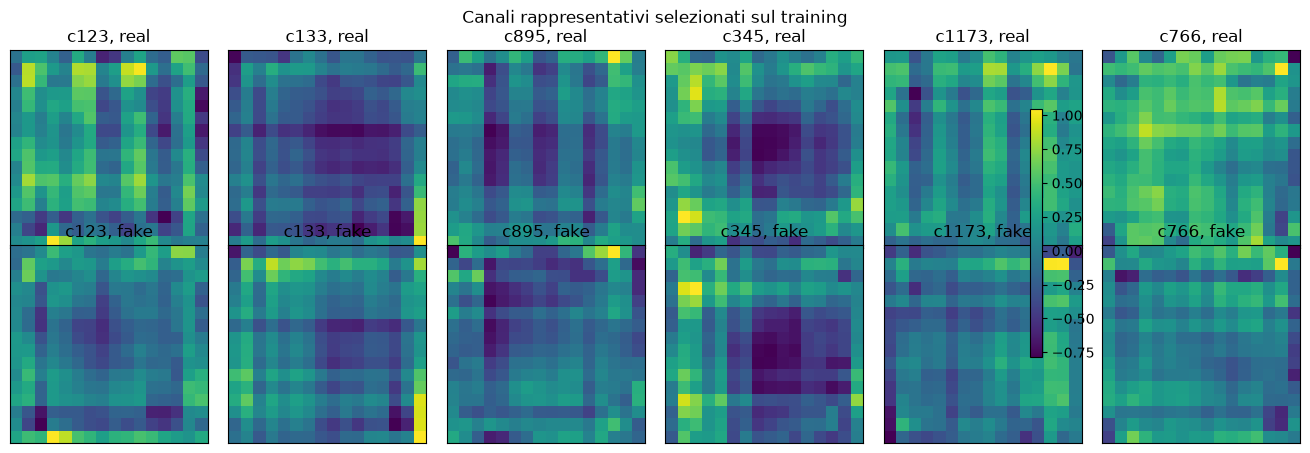

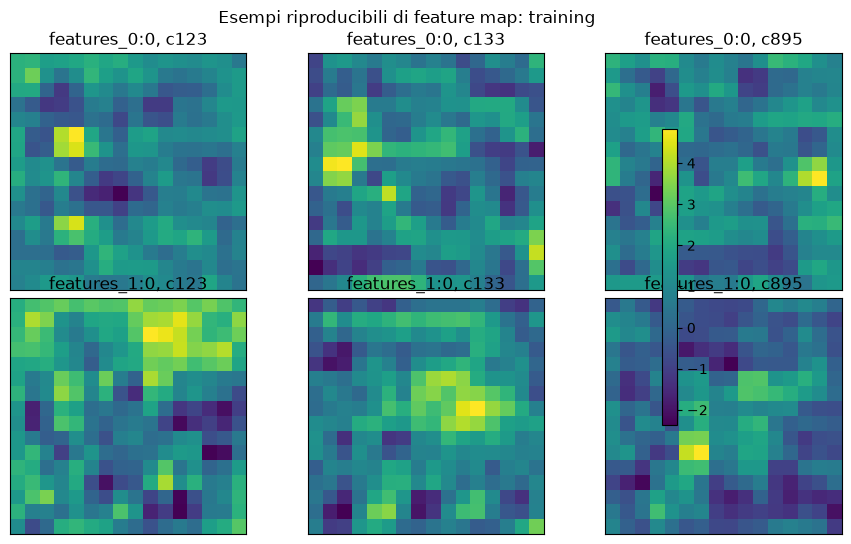

In [10]:
# I canali e gli esempi sono scelti in modo deterministico dal training per rendere la figura riproducibile.
representative_channels = top_channels[:6]
channel_map_sums = {0: np.zeros((len(representative_channels), 16, 16), dtype=np.float64), 1: np.zeros((len(representative_channels), 16, 16), dtype=np.float64)}
for _, global_start, batch in feature_batches():
    global_ids = np.arange(global_start, global_start + len(batch))
    selected = batch[train_mask[global_ids]]
    selected_labels = labels[global_ids[train_mask[global_ids]]]
    for label in (0, 1):
        current = selected[selected_labels == label]
        if len(current):
            channel_map_sums[label] += current[:, representative_channels].sum(axis=0)
fig, axes = plt.subplots(2, len(representative_channels), figsize=(2.2 * len(representative_channels), 4.6))
for row, label in enumerate((0, 1)):
    for column, channel in enumerate(representative_channels):
        image = axes[row, column].imshow(channel_map_sums[label][column] / spatial_counts[label], cmap='viridis')
        axes[row, column].set_title(f'c{channel}, {"real" if label == 0 else "fake"}')
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.7)
fig.suptitle('Canali rappresentativi selezionati sul training')
save_figure('representative_channel_maps.png')

example_indices = [train_indices[np.flatnonzero(train_labels == label)[0]] for label in (0, 1)]
fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
for row, global_index in enumerate(example_indices):
    sample = np.asarray(features_real[global_index] if global_index < N_REAL else features_fake[global_index - N_REAL], dtype=np.float32)
    for column, channel in enumerate(representative_channels[:3]):
        image = axes[row, column].imshow(sample[channel], cmap='viridis')
        axes[row, column].set_title(f'{sample_ids[global_index]}, c{channel}')
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.7)
fig.suptitle('Esempi riproducibili di feature map: training')
save_figure('representative_feature_maps.png')

## 8. Baseline diagnostica dei confondenti e riepilogo

La regressione logistica seguente è un controllo diagnostico, non un classificatore finale: usa soltanto media, deviazione standard, minimo e massimo globali. È addestrata sul training e misurata sulla validation; il test resta completamente inutilizzato.

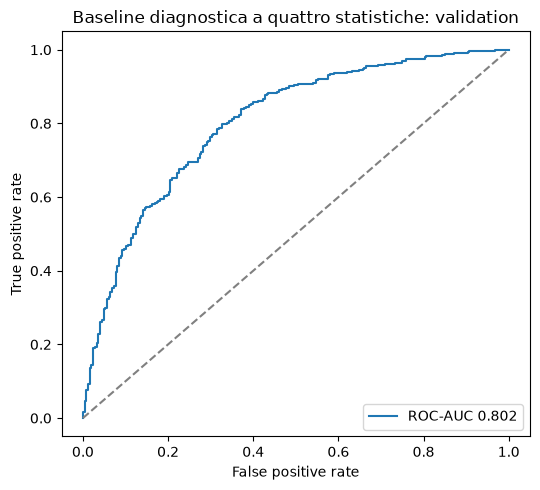

   balanced_accuracy   roc_auc fit_split evaluation_split  \
0           0.733184  0.801867     train       validation   

                                            features  
0  [global_mean, global_std, global_min, global_max]  
Artefatti prodotti:
- manifest: c:\Users\leona\venv_aml\artifacts\dataset_manifest.json
- split: c:\Users\leona\venv_aml\artifacts\splits_seed42.npz
- sample_index: c:\Users\leona\venv_aml\dataset\sample_index.csv
- gap_cache: c:\Users\leona\venv_aml\dataset\tabular_features_gap.npy
- mean_std_cache: c:\Users\leona\venv_aml\dataset\tabular_features_mean_std.npy
- spatial_normalization: c:\Users\leona\venv_aml\dataset\spatial_channel_normalization.npz
- run_directory: c:\Users\leona\venv_aml\results\dataset_exploration\seed42_20260916T132745Z


In [11]:
# Questa baseline quantifica quanto segnale sia disponibile in statistiche molto semplici e quindi il rischio di bias.
diagnostic_features = sample_stats[:, :4].astype(np.float32)
diagnostic_model = Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression(max_iter=2000, random_state=SEED, class_weight='balanced'))])
diagnostic_model.fit(diagnostic_features[train_indices], labels[train_indices])
validation_probability = diagnostic_model.predict_proba(diagnostic_features[validation_indices])[:, POSITIVE_LABEL]
validation_prediction = (validation_probability >= 0.5).astype(np.int8)
diagnostic_metrics = {'balanced_accuracy': float(balanced_accuracy_score(labels[validation_indices], validation_prediction)), 'roc_auc': float(roc_auc_score(labels[validation_indices], validation_probability)), 'fit_split': 'train', 'evaluation_split': 'validation', 'features': ['global_mean', 'global_std', 'global_min', 'global_max']}
fpr, tpr, _ = roc_curve(labels[validation_indices], validation_probability, pos_label=POSITIVE_LABEL)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC {diagnostic_metrics["roc_auc"]:.3f}')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.title('Baseline diagnostica a quattro statistiche: validation')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')
save_figure('diagnostic_baseline_roc.png')

read_started = time.perf_counter()
_, _, benchmark_batch = next(feature_batches())
read_seconds = time.perf_counter() - read_started
loading_performance = {'mmap_open_seconds': mmap_open_seconds, 'batch_size': BATCH_SIZE, 'first_batch_mib': benchmark_batch.nbytes / 1024**2, 'first_batch_seconds': read_seconds, 'first_batch_mib_per_second': benchmark_batch.nbytes / max(read_seconds, np.finfo(float).eps) / 1024**2, 'note': 'Misura leggera, influenzata dalla cache del sistema e dallo storage.'}

# Manifest e summary registrano configurazione, split hash e output per rendere tracciabile ogni esecuzione.
manifest = {'generated_at_utc': datetime.now(timezone.utc).isoformat(), 'seed': SEED, 'class_mapping': CLASS_MAPPING, 'positive_class': {'label': POSITIVE_LABEL, 'name': POSITIVE_CLASS}, 'source_files': INVENTORIES, 'total_samples': N_TOTAL, 'sample_shape': list(EXPECTED_SAMPLE_SHAPE), 'sample_dtype': str(EXPECTED_DTYPE), 'pooling': {'gap': 'channel mean over spatial dimensions', 'mean_std': 'means followed by population standard deviations'}, 'split': {'path': SPLIT_PATH.name, 'hash': SPLIT_HASH, 'origin': split_origin, 'summary': SPLIT_SUMMARY}, 'numeric_quality': quality, 'exact_duplicates': duplicate_summary, 'normalization': {'path': NORMALIZATION_PATH.name, 'epsilon': EPSILON, 'fit_scope': 'training split only'}, 'versions': VERSIONS}
atomic_json(manifest, ARTIFACTS_DIR / 'dataset_manifest.json')
summary = {'run_id': RUN_ID, 'generated_at_utc': datetime.now(timezone.utc).isoformat(), 'dataset': {'n_total': N_TOTAL, 'n_real': N_REAL, 'n_fake': N_FAKE, 'majority_baseline_accuracy': max(N_REAL, N_FAKE) / N_TOTAL}, 'split_hash': SPLIT_HASH, 'split_summary': SPLIT_SUMMARY, 'numeric_quality': quality, 'exact_duplicates': duplicate_summary, 'effect_size_channel_fractions': effect_size_fractions, 'diagnostic_baseline_validation': diagnostic_metrics, 'loading_performance': loading_performance, 'limitations': ['Le analisi class-conditional usano esclusivamente il training.', 'La baseline diagnostica usa training e validation, non il test.', 'Non sono disponibili ID di gruppo per uno split group-aware.', 'I percentili delle attivazioni provengono da un campione deterministico per contenere memoria e tempo.'], 'artifacts': {'manifest': str(ARTIFACTS_DIR / 'dataset_manifest.json'), 'split': str(SPLIT_PATH), 'sample_index': str(PROCESSED_DATASET_DIR / 'sample_index.csv'), 'gap_cache': str(GAP_PATH), 'mean_std_cache': str(MEAN_STD_PATH), 'spatial_normalization': str(NORMALIZATION_PATH), 'run_directory': str(RUN_DIR)}}
atomic_json(summary, RUN_DIR / 'summary.json')
print(pd.DataFrame([diagnostic_metrics]))
print('Artefatti prodotti:')
for name, path in summary['artifacts'].items():
    print(f'- {name}: {path}')
if diagnostic_metrics['balanced_accuracy'] >= 0.75:
    print('Attenzione: la baseline globale è elevata; discutere possibili bias di acquisizione o preprocessing.')